## Notebook 17 — Audit of the CNN Reference Point
**Project:** Machine Learning for High Performance Optical Sorting
**Author:** Mohamed Tawfeek
**Description:** Three checks on the claims notebook 16 supports: where the glass/metal fix came from, whether near-duplicate images leak between train and test, and how much of the result is one lucky seed

Notebook 16 reported 95.00% for a fine-tuned ResNet18 and a glass/metal off-diagonal of 2
against 16 for the Random Forest and 17 for the MLP. On the strength of that, finding 1 in
the README withdrew its sensor recommendation and claimed the descriptor had been discarding
information the reflected visible light carried all along.

That is a large claim resting on one training run, and three things about it are untested.

**The images were not held fixed.** The ResNet18 starts from `IMAGENET1K_V1`, so it saw 1.28
million images before it saw one from TrashNet. Whether the fix came from ImageNet's
representation or from the 1,769 TrashNet training images decides what finding 1 is entitled
to say, and notebook 16 does not separate them.

**The split is by image, not by object.** TrashNet was collected by photographing objects on
a posterboard, and the same physical object appears in several images at different angles.
Shuffling images can therefore put near-copies of one object in both train and test. That
inflates every model here, but not equally: a convolutional stack can key on a specific dent
or label that a 32-bin global HSV histogram discards, so the CNN's margin is the number most
exposed to it.

**Small counts are being read as signal.** Notebook 15 would not accept a six-image gap
between the RF and the MLP without McNemar and a five-seed sweep. The CNN row is one seed,
and the claims built on it involve counts of 2 and 3.

This notebook runs those three checks. It trains new models but writes nothing any earlier
notebook reads: every artifact it saves is prefixed `audit_`, and `cnn_final_model.pt` is
read and never rewritten. The point is to find out whether the notebook 16 rewrite was
justified, not to defend it.

In [1]:
import json
import os
import pickle
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, os.path.abspath('..'))

In [2]:
from src.features import CLASSES, CLASS_ORDER, IMAGE_SIZE, list_class_images
from src.split import split_indices

DATASET_PATH  = os.path.join('..', 'datasets', 'dataset-resized')
FEATURES_PATH = os.path.join('..', 'results', 'features')
RESULTS_PATH  = os.path.join('..', 'results')
FIGURES_PATH  = os.path.join('..', 'results', 'figures')

RANDOM_STATE = 42
SEEDS = [42, 1, 7, 13, 99]          # the seeds notebook 15 sweeps

# Training recipe held identical to notebook 16 throughout this notebook.
EPOCHS        = 20
BATCH_SIZE    = 32
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

SIMILARITY_THRESHOLDS = [0.85, 0.90, 0.93, 0.95, 0.97]
SMALL_SUBSET = 200                  # below this, pair counts carry little weight

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"torch {torch.__version__}, device {device}")

torch 2.11.0+cu128, device cuda


### The same test partition, asserted rather than assumed

Identical check to notebook 16: index the committed feature matrix by the test indices,
score the committed Random Forest pickle, and compare against the committed confusion matrix.

In [3]:
all_labels   = np.load(os.path.join(FEATURES_PATH, 'labels.npy'))
all_features = np.load(os.path.join(FEATURES_PATH, 'features.npy'))
image_paths  = np.array([p for c in CLASSES for p in list_class_images(DATASET_PATH, c)])

assert np.array_equal(
    np.array([os.path.basename(os.path.dirname(p)) for p in image_paths]), all_labels
), "image path order does not match labels.npy"

train_idx, val_idx, test_idx = split_indices(all_labels)

with open(os.path.join(RESULTS_PATH, 'rf_final_model.pkl'), 'rb') as f:
    rf_model = pickle.load(f)

rf_cm_committed = np.load(os.path.join(RESULTS_PATH, 'rf_confusion_matrix.npy'))
assert np.array_equal(
    confusion_matrix(all_labels[test_idx], rf_model.predict(all_features[test_idx]),
                     labels=CLASS_ORDER),
    rf_cm_committed
), "Reproduced test partition does not match the committed RF confusion matrix"

print(f"Split {len(train_idx)} / {len(val_idx)} / {len(test_idx)}, verified against "
      f"results/rf_confusion_matrix.npy")

Split 1769 / 378 / 380, verified against results/rf_confusion_matrix.npy


In [4]:
# Every image resized once into a uint8 cache. This is the same Pillow call src/features.py
# and notebook 16 make, so the cache is bit-identical to decoding per epoch; the assert
# below checks that rather than trusting it. Five training runs of 20 epochs each would
# otherwise spend most of their time in JPEG decoding.

start = time.perf_counter()
image_cache = np.stack([
    np.asarray(Image.open(p).convert('RGB').resize(IMAGE_SIZE), dtype=np.uint8)
    for p in image_paths
])
print(f"Cached {image_cache.shape[0]} images at {IMAGE_SIZE}, "
      f"{image_cache.nbytes / 1e6:.0f} MB, in {time.perf_counter() - start:.1f}s")


def to_tensor_pil(pil_image):
    """Notebook 16's exact preprocessing path, kept here as the reference implementation."""
    array = np.asarray(pil_image.resize(IMAGE_SIZE), dtype=np.float32) / 255.0
    array = (array - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(array.transpose(2, 0, 1).astype(np.float32))


def to_tensor(index_or_array):
    array = image_cache[index_or_array] if np.isscalar(index_or_array) else index_or_array
    array = array.astype(np.float32) / 255.0
    array = (array - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(array.transpose(2, 0, 1).astype(np.float32))


for probe in [0, 977, 2526]:
    assert torch.equal(
        to_tensor_pil(Image.open(image_paths[probe]).convert('RGB')), to_tensor(probe)
    ), f"cache diverges from the PIL path at index {probe}"

print("Cache is bit-identical to notebook 16's preprocessing path")

Cached 2527 images at (224, 224), 380 MB, in 6.5s
Cache is bit-identical to notebook 16's preprocessing path


In [5]:
CLASS_TO_INDEX = {c: i for i, c in enumerate(CLASS_ORDER)}


class CachedImages(Dataset):
    def __init__(self, indices, train=False):
        self.indices = indices
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        array = image_cache[self.indices[i]]
        if self.train and random.random() < 0.5:
            array = array[:, ::-1, :]                      # horizontal flip, as notebook 16
        return to_tensor(np.ascontiguousarray(array)), CLASS_TO_INDEX[all_labels[self.indices[i]]]


def make_loader(indices, train=False):
    return DataLoader(CachedImages(indices, train=train),
                      batch_size=BATCH_SIZE, shuffle=train, num_workers=0)


def seed_everything(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def build_model(pretrained=True):
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, len(CLASS_ORDER))
    return model.to(device)


@torch.no_grad()
def predict(model, loader):
    model.eval()
    preds, trues = [], []
    for x, y in loader:
        preds.append(model(x.to(device)).argmax(1).cpu().numpy())
        trues.append(y.numpy())
    return (np.array(CLASS_ORDER)[np.concatenate(preds)],
            np.array(CLASS_ORDER)[np.concatenate(trues)])


GLASS = CLASS_ORDER.index('glass')
METAL = CLASS_ORDER.index('metal')


def pair_and_errors(cm):
    """Glass/metal off-diagonal total and total errors from a confusion matrix."""
    return int(cm[GLASS, METAL] + cm[METAL, GLASS]), int(cm.sum() - np.trace(cm))


def score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
    pair, errors = pair_and_errors(cm)
    return {'Accuracy': accuracy_score(y_true, y_pred), 'Pair': pair, 'Errors': errors}


print("Helpers defined")

Helpers defined


### Reproducing notebook 16's predictions

The duplicate audit needs per-image predictions from the committed model, which notebook 16
saved only as a confusion matrix. They are regenerated here from `cnn_final_model.pt` and
asserted against `cnn_confusion_matrix.npy`, so the audit works on exactly the predictions
notebook 16 reported and the network is never retrained for this purpose.

One detail worth recording, because it bears on the third check. Reproducing that confusion
matrix exactly requires the same device and batch size notebook 16 used, CUDA at batch 32.
On CPU, or on CUDA at batch 64, one image flips and the accuracy reads 94.74% instead of
95.00%. Nothing is wrong with either number; it means one test image sits close enough to a
decision boundary that the choice of convolution algorithm decides it. The committed 95.00%
is one borderline image away from 94.74%.

In [6]:
seed_everything()

checkpoint = torch.load(os.path.join(RESULTS_PATH, 'cnn_final_model.pt'), map_location='cpu')
cnn_model = models.resnet18()
cnn_model.fc = nn.Linear(cnn_model.fc.in_features, len(CLASS_ORDER))
cnn_model.load_state_dict(checkpoint['state_dict'])
cnn_model.to(device).eval()

cnn_pred, cnn_true = predict(cnn_model, make_loader(test_idx))
cnn_cm_committed = np.load(os.path.join(RESULTS_PATH, 'cnn_confusion_matrix.npy'))

assert np.array_equal(
    confusion_matrix(cnn_true, cnn_pred, labels=CLASS_ORDER), cnn_cm_committed
), "Regenerated CNN predictions do not reproduce the committed confusion matrix"

pd.DataFrame({
    'image': [os.path.basename(p) for p in image_paths[test_idx]],
    'true': cnn_true,
    'predicted': cnn_pred,
}).to_csv(os.path.join(RESULTS_PATH, 'audit_cnn_test_predictions.csv'), index=False)

print(f"Reproduced notebook 16 predictions exactly. Accuracy "
      f"{accuracy_score(cnn_true, cnn_pred):.4f}, {score(cnn_true, cnn_pred)}")

Reproduced notebook 16 predictions exactly. Accuracy 0.9500, {'Accuracy': 0.95, 'Pair': 2, 'Errors': 19}


## 1. Where the glass/metal fix came from

Two more models on the same test partition, to split ImageNet's contribution from TrashNet's.

**Frozen probe.** The ImageNet-pretrained ResNet18 with no fine-tuning at all. Every image
goes through it, the 512-dim penultimate activations are kept, and a logistic regression is
fitted on the training partition only. This is ImageNet's representation with a classifier
fitted to TrashNet, and it is the direct analogue of the existing logistic-regression-on-122-features
row. `C` is selected by the same rule notebook 14 uses, 5-fold stratified cross-validation on
weighted F1 over the training partition, taking the most stable configuration within 0.005 of
the best mean.

**From scratch.** A ResNet18 with random initialisation, trained on the same 1,769 images
with the same optimiser, schedule, epoch budget, augmentation and validation-selected epoch.
This is TrashNet's pixels with no ImageNet. It should be much weaker overall, which is the
measurement rather than a failure.

In [7]:
@torch.no_grad()
def extract_penultimate(model, indices, batch_size=64):
    """512-dim penultimate activations, no augmentation, eval mode."""
    model.eval()
    out = []
    for i in range(0, len(indices), batch_size):
        batch = torch.stack([to_tensor(int(j)) for j in indices[i:i + batch_size]]).to(device)
        out.append(model(batch).cpu().numpy())
    return np.concatenate(out)


def penultimate_model(state_dict=None):
    """ResNet18 truncated at the pooled 512-dim layer."""
    if state_dict is None:
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    else:
        model = models.resnet18()
        model.fc = nn.Linear(model.fc.in_features, len(CLASS_ORDER))
        model.load_state_dict(state_dict)
    model.fc = nn.Identity()
    return model.to(device)


start = time.perf_counter()
imagenet_features = extract_penultimate(penultimate_model(), np.arange(len(image_paths)))
print(f"Frozen ImageNet features {imagenet_features.shape} in {time.perf_counter() - start:.1f}s")

Frozen ImageNet features (2527, 512) in 5.8s


In [8]:
# Notebook 14's selection rule, reused so the probe is tuned the way the classical linear
# models were rather than at a hand-picked C.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
TOLERANCE = 0.005


def select_c(make_model, c_options, X, y, label):
    means, stds = [], []
    for c in c_options:
        scores = cross_val_score(make_model(c), X, y, cv=cv, scoring='f1_weighted', n_jobs=-1)
        means.append(scores.mean())
        stds.append(scores.std())
        print(f"C={c:<8} - Mean weighted F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

    means, stds = np.array(means), np.array(stds)
    within_noise = np.flatnonzero(means >= means.max() - TOLERANCE)
    chosen = within_noise[np.argmin(stds[within_noise])]
    print(f"Selected {label} C: {c_options[chosen]}")
    return c_options[chosen]


def make_probe(c):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=c, max_iter=2000, random_state=RANDOM_STATE)),
    ])


print("=== Frozen ImageNet probe ===")
probe_c = select_c(make_probe, [0.01, 0.1, 1.0, 10.0, 100.0],
                   imagenet_features[train_idx], all_labels[train_idx], "frozen probe")

probe = make_probe(probe_c)
probe.fit(imagenet_features[train_idx], all_labels[train_idx])
probe_pred = probe.predict(imagenet_features[test_idx])
probe_score = score(all_labels[test_idx], probe_pred)

print(f"\nFrozen probe test: {probe_score}")

=== Frozen ImageNet probe ===


C=0.01     - Mean weighted F1: 0.8298 (+/- 0.0105)


C=0.1      - Mean weighted F1: 0.8235 (+/- 0.0151)


C=1.0      - Mean weighted F1: 0.8137 (+/- 0.0104)


C=10.0     - Mean weighted F1: 0.8115 (+/- 0.0148)


C=100.0    - Mean weighted F1: 0.8006 (+/- 0.0158)
Selected frozen probe C: 0.01

Frozen probe test: {'Accuracy': 0.85, 'Pair': 12, 'Errors': 57}


In [9]:
def train_resnet(indices_train, indices_val, seed, pretrained=True, label=""):
    """Notebook 16's training loop. Returns (best_state, best_epoch, best_val_accuracy)."""
    seed_everything(seed)

    model = build_model(pretrained=pretrained)
    optimiser = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                                  weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss()

    train_loader = make_loader(indices_train, train=True)
    val_loader = make_loader(indices_val)

    best_val, best_state, best_epoch = 0.0, None, 0
    start = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimiser.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimiser.step()
        scheduler.step()

        val_pred, val_true = predict(model, val_loader)
        val_accuracy = accuracy_score(val_true, val_pred)
        if val_accuracy > best_val:
            best_val, best_epoch = val_accuracy, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f"  {label} trained in {time.perf_counter() - start:.0f}s, "
          f"best val {best_val:.4f} at epoch {best_epoch}")
    model.load_state_dict(best_state)
    return model, best_state, best_epoch, best_val


print("=== ResNet18 from scratch (no ImageNet) ===")
scratch_model, scratch_state, _, _ = train_resnet(
    train_idx, val_idx, RANDOM_STATE, pretrained=False, label="from scratch"
)
scratch_pred, scratch_true = predict(scratch_model, make_loader(test_idx))
scratch_score = score(scratch_true, scratch_pred)
print(f"From scratch test: {scratch_score}")

=== ResNet18 from scratch (no ImageNet) ===


  from scratch trained in 99s, best val 0.8598 at epoch 17


From scratch test: {'Accuracy': 0.8078947368421052, 'Pair': 13, 'Errors': 73}


In [10]:
# Both alternatives above are single runs, and section 3 measures the fine-tuned network's
# pair count at a standard deviation of about 4.4. Comparing n=1 against that is not a
# comparison, so both are swept over the same five seeds, with the seed driving the split as
# it does everywhere else. C is reselected inside each seed rather than reusing seed 42's.

C_OPTIONS = [0.01, 0.1, 1.0, 10.0, 100.0]


def run_probe_seed(seed):
    tr, _, te = split_indices(all_labels, seed)
    c = select_c(make_probe, C_OPTIONS, imagenet_features[tr], all_labels[tr],
                 f"frozen probe seed {seed}")
    model = make_probe(c)
    model.fit(imagenet_features[tr], all_labels[tr])
    return {'Seed': seed, 'C': c, **score(all_labels[te], model.predict(imagenet_features[te]))}


def run_scratch_seed(seed):
    tr, va, te = split_indices(all_labels, seed)
    model, _, best_epoch, _ = train_resnet(tr, va, seed, pretrained=False,
                                           label=f"from scratch seed {seed}")
    pred, true = predict(model, make_loader(te))
    return {'Seed': seed, 'Best epoch': best_epoch, **score(true, pred)}


print("=== Frozen ImageNet probe, five seeds ===")
probe_seeds = pd.DataFrame([run_probe_seed(s) for s in SEEDS])

print("\n=== ResNet18 from scratch, five seeds ===")
scratch_seeds = pd.DataFrame([run_scratch_seed(s) for s in SEEDS])

for frame in (probe_seeds, scratch_seeds):
    frame['Pair share'] = (frame['Pair'] / frame['Errors']).round(4)

# The seed-42 rows must agree with the single runs above. This checks the sweep reproduces
# them rather than being a separate measurement that happens to look similar.
assert probe_seeds.loc[probe_seeds.Seed == 42, 'Pair'].iloc[0] == probe_score['Pair']
assert scratch_seeds.loc[scratch_seeds.Seed == 42, 'Pair'].iloc[0] == scratch_score['Pair']

print("\nFrozen ImageNet probe, five seeds:")
print(probe_seeds.to_string(index=False))
print("\nResNet18 from scratch, five seeds:")
print(scratch_seeds.to_string(index=False))

for name, frame in [('Frozen probe', probe_seeds), ('From scratch', scratch_seeds)]:
    print(f"\n{name}: accuracy {frame['Accuracy'].mean():.4f} +/- {frame['Accuracy'].std():.4f}, "
          f"pair {frame['Pair'].mean():.2f} +/- {frame['Pair'].std():.2f}, "
          f"errors {frame['Errors'].mean():.2f} +/- {frame['Errors'].std():.2f}, "
          f"share {frame['Pair share'].mean() * 100:.1f}% +/- {frame['Pair share'].std() * 100:.1f}")

=== Frozen ImageNet probe, five seeds ===


C=0.01     - Mean weighted F1: 0.8298 (+/- 0.0105)


C=0.1      - Mean weighted F1: 0.8235 (+/- 0.0151)


C=1.0      - Mean weighted F1: 0.8137 (+/- 0.0104)


C=10.0     - Mean weighted F1: 0.8115 (+/- 0.0148)


...

  from scratch seed 1 trained in 102s, best val 0.7804 at epoch 17


  from scratch seed 7 trained in 105s, best val 0.7963 at epoch 14


  from scratch seed 13 trained in 105s, best val 0.8016 at epoch 13


  from scratch seed 99 trained in 105s, best val 0.8254 at epoch 16



Frozen ImageNet probe, five seeds:
 Seed    C  Accuracy  Pair  Errors  Pair share
   42 0.01  0.850000    12      57      0.2105
    1 0.01  0.834211    13      63      0.2063
    7 0.01  0.828947    13      65      0.2000
   13 0.01  0.826316    18      66      0.2727
   99 0.10  0.828947    13      65      0.2000

ResNet18 from scratch, five seeds:
 Seed  Best epoch  Accuracy  Pair  Errors  Pair share
   42          17  0.807895    13      73      0.1781
    1          17  0.813158    14      71      0.1972
    7          14  0.786842    17      81      0.2099
   13          13  0.794737    23      78      0.2949
   99          16  0.765789    20      89      0.2247

Frozen probe: accuracy 0.8337 +/- 0.0096, pair 13.80 +/- 2.39, errors 63.20 +/- 3.63, share 21.8% +/- 3.1

From scratch: accuracy 0.7937 +/- 0.0188, pair 17.40 +/- 4.16, errors 78.40 +/- 7.13, share 22.1% +/- 4.5


In [11]:
# One table: the four classical models from their committed confusion matrices, then the
# three CNN variants at seed 42 with their five-seed spreads alongside. The pair share is
# reported next to the absolute count throughout, because the two say different things and
# the count on its own is misleading once total errors differ by a factor of six.

CLASSICAL = {
    'Logistic Regression (122-dim)': 'logreg_confusion_matrix.npy',
    'Linear SVC (122-dim)':          'linsvc_confusion_matrix.npy',
    'Random Forest (122-dim)':       'rf_confusion_matrix.npy',
    'MLP (122-dim)':                 'mlp_confusion_matrix.npy',
}

cnn_pair_committed, cnn_errors_committed = pair_and_errors(cnn_cm_committed)

rows = []
for name, filename in CLASSICAL.items():
    cm = np.load(os.path.join(RESULTS_PATH, filename))
    pair, errors = pair_and_errors(cm)
    rows.append({'Model': name, 'Representation': 'HSV+LBP, hand-designed',
                 'Accuracy': np.trace(cm) / cm.sum(), 'Glass/metal pair': pair,
                 'Total errors': errors, 'Pair share': pair / errors})

for name, representation_label, frame, single in [
    ('ResNet18 from scratch', 'learned, TrashNet only', scratch_seeds, scratch_score),
    ('Frozen ImageNet probe', 'ImageNet, not fine-tuned', probe_seeds, probe_score),
]:
    rows.append({'Model': f'{name} (seed 42)', 'Representation': representation_label,
                 'Accuracy': single['Accuracy'], 'Glass/metal pair': single['Pair'],
                 'Total errors': single['Errors'],
                 'Pair share': single['Pair'] / single['Errors']})
    rows.append({'Model': f'{name} (5-seed mean)', 'Representation': representation_label,
                 'Accuracy': frame['Accuracy'].mean(), 'Glass/metal pair': frame['Pair'].mean(),
                 'Total errors': frame['Errors'].mean(),
                 'Pair share': frame['Pair share'].mean()})

rows.append({'Model': 'ResNet18 fine-tuned (seed 42, notebook 16)',
             'Representation': 'ImageNet, fine-tuned',
             'Accuracy': accuracy_score(cnn_true, cnn_pred),
             'Glass/metal pair': cnn_pair_committed, 'Total errors': cnn_errors_committed,
             'Pair share': cnn_pair_committed / cnn_errors_committed})

representation = pd.DataFrame(rows)
representation['Accuracy'] = representation['Accuracy'].round(4)
representation['Pair share'] = representation['Pair share'].round(4)
representation.to_csv(os.path.join(RESULTS_PATH, 'audit_representation_comparison.csv'),
                      index=False)

print("The fine-tuned five-seed row is added in section 3, once its sweep has run.\n")
print(representation.to_string(index=False))

The fine-tuned five-seed row is added in section 3, once its sweep has run.

                                     Model           Representation  Accuracy  Glass/metal pair  Total errors  Pair share
             Logistic Regression (122-dim)   HSV+LBP, hand-designed    0.6895              21.0         118.0      0.1780
                      Linear SVC (122-dim)   HSV+LBP, hand-designed    0.6711              25.0         125.0      0.2000
                   Random Forest (122-dim)   HSV+LBP, hand-designed    0.7895              16.0          80.0      0.2000
                             MLP (122-dim)   HSV+LBP, hand-designed    0.8053              17.0          74.0      0.2297
           ResNet18 from scratch (seed 42)   learned, TrashNet only    0.8079              13.0          73.0      0.1781
       ResNet18 from scratch (5-seed mean)   learned, TrashNet only    0.7937              17.4          78.4      0.2210
           Frozen ImageNet probe (seed 42) ImageNet, not fine-tuned  

### Reading section 1

Neither ingredient on its own moves the pair. Across five seeds ImageNet's representation
with a logistic regression on top puts 13.8 ± 2.4 on the glass/metal off-diagonal, and a
network that learns its representation from the TrashNet training images alone puts
17.4 ± 4.2, against 16 for the Random Forest and 17 for the MLP. The fine-tuned network puts
7.6 ± 4.4. Only the combination moves the absolute count, and even then by roughly half
rather than to the 2 that seed 42 produced.

The share of each model's own errors says something different from the absolute count, and
it is the number that controls for the fact that a more accurate model makes fewer of every
kind of mistake. Across the five seeds the pair is 10.5%, 20.0%, 17.6%, 35.1% and 37.9% of
the fine-tuned network's errors, a mean of 24.2% ± 11.8. The frozen probe is at 21.8%, the
from-scratch network at 22.1%, the Random Forest at 20.0% and the MLP at 23.0%. Every
representation tried here sits in the same band. The fine-tuned network's pair count falls
because its total errors fall, not because glass and metal became relatively easier for it,
and seed 42's 10.5% is the only figure in the set that suggested otherwise.

That is a narrower conclusion than notebook 16 licensed, and narrower than the first version
of this notebook drew. It is not true that any learned representation dissolves the
glass/metal confusion, because the one learned from these 1,769 images does not: at
79.37% ± 1.88 accuracy the from-scratch ResNet18 does not beat the MLP's 80.05% ± 1.88 from
notebook 15. And it is not true that the fine-tuned network changes the character of the
failure, because proportionally the pair is as dominant for it as for everything else.

Two consequences for finding 1. The phrase "holding the sensor, the images and the split
fixed" is wrong, because the images were not held fixed. And the claim that the descriptor
was discarding information the visible light carried needs splitting in two: the accuracy
ceiling does move when the representation changes, but glass against metal stays the hardest
distinction in the dataset for every representation tried, which is not what an artifact of
the HSV and LBP descriptors would look like.

## 2. Near-duplicate audit

TrashNet was collected by photographing objects on a posterboard, so the same physical object
appears in several images. The split shuffles images, not objects, so near-copies can land on
both sides of it.

Similarity is cosine distance between the fine-tuned network's 512-dim penultimate features.
No single threshold is defensible, so five are swept. At each, test images whose maximum
similarity to any training image exceeds the threshold are flagged, and every model is
re-scored on what is left. Nothing is retrained: the classical models come from their
committed pickles indexed on the committed feature matrix, and the CNN row is a subset of the
predictions verified above.

Duplicates lying entirely within the test set are harmless and are not removed, since nothing
leaks between two test images. Only train-to-test proximity matters here.

In [12]:
# Two similarity bases, because the choice of ruler turns out to matter.
#
# The fine-tuned network's own features are the obvious choice and the wrong one on their
# own: fine-tuning pulls same-class images together by construction, so two unrelated bottles
# score high simply for both being plastic. The frozen ImageNet features were never fitted to
# these six classes and are independent of both the fine-tuning and the classical models,
# which makes them the better ruler for object identity. Both are computed here and the sweep
# is run on each.

finetuned_features = extract_penultimate(
    penultimate_model(checkpoint['state_dict']), np.arange(len(image_paths))
)


def similarity_basis(features):
    """Max cosine similarity of each test image to any training image, and which one."""
    unit = features / np.linalg.norm(features, axis=1, keepdims=True)
    sim = unit[test_idx] @ unit[train_idx].T
    return sim.max(axis=1), sim.argmax(axis=1)


max_similarity, nearest_train = similarity_basis(finetuned_features)
imagenet_max, imagenet_nearest = similarity_basis(imagenet_features)

print("Cosine similarity of each test image to its nearest training image:\n")
print(f"{'percentile':>12}  {'fine-tuned':>11}  {'frozen ImageNet':>16}")
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 1.00]:
    print(f"{int(q * 100):>11}th  {np.quantile(max_similarity, q):>11.4f}  "
          f"{np.quantile(imagenet_max, q):>16.4f}")

Cosine similarity of each test image to its nearest training image:

  percentile   fine-tuned   frozen ImageNet
         10th       0.8345            0.7898
         25th       0.8817            0.8187
         50th       0.9180            0.8443
         75th       0.9403            0.8764
         90th       0.9534            0.9018
        100th       1.0000            1.0000


In [13]:
# Classical models re-scored by indexing the committed feature matrix. No retraining anywhere
# in this section: the RF and MLP come from their committed pickles and the CNN row is a
# subset of the predictions asserted against the committed confusion matrix above.

with open(os.path.join(RESULTS_PATH, 'mlp_final_model.pkl'), 'rb') as f:
    mlp_model = pickle.load(f)
with open(os.path.join(RESULTS_PATH, 'mlp_scaler.pkl'), 'rb') as f:
    mlp_scaler = pickle.load(f)

rf_test_pred  = rf_model.predict(all_features[test_idx])
mlp_test_pred = mlp_model.predict(mlp_scaler.transform(all_features[test_idx]))
y_test = all_labels[test_idx]

assert np.array_equal(confusion_matrix(y_test, rf_test_pred, labels=CLASS_ORDER), rf_cm_committed)
assert np.array_equal(
    confusion_matrix(y_test, mlp_test_pred, labels=CLASS_ORDER),
    np.load(os.path.join(RESULTS_PATH, 'mlp_confusion_matrix.npy'))
)


def duplicate_sweep(similarity_scores):
    """Re-score every model on the subset left after removing flagged test images."""
    rows = []
    for threshold in [1.0] + SIMILARITY_THRESHOLDS:
        keep = (similarity_scores <= threshold if threshold < 1.0
                else np.ones(len(test_idx), bool))

        rf_s  = score(y_test[keep], rf_test_pred[keep])
        mlp_s = score(y_test[keep], mlp_test_pred[keep])
        cnn_s = score(cnn_true[keep], cnn_pred[keep])

        rows.append({
            'Threshold': threshold,
            'Flagged': int((~keep).sum()),
            'Subset size': int(keep.sum()),
            'RF accuracy': round(rf_s['Accuracy'], 4),
            'MLP accuracy': round(mlp_s['Accuracy'], 4),
            'CNN accuracy': round(cnn_s['Accuracy'], 4),
            'CNN minus MLP': round(cnn_s['Accuracy'] - mlp_s['Accuracy'], 4),
            'RF pair': rf_s['Pair'],
            'MLP pair': mlp_s['Pair'],
            'CNN pair': cnn_s['Pair'],
        })
    return pd.DataFrame(rows)


sweep = duplicate_sweep(max_similarity)
sweep.to_csv(os.path.join(RESULTS_PATH, 'audit_duplicate_threshold_sweep.csv'), index=False)

print("Basis: the fine-tuned network's own features.")
print("Threshold 1.0 is the full test set, zero flagged, for direct comparison.\n")
print(sweep.to_string(index=False))

small = sweep[sweep['Subset size'] < SMALL_SUBSET]['Threshold'].tolist()
print(f"\nSubsets below {SMALL_SUBSET} images, where pair counts carry little weight: "
      f"thresholds {small}")

Basis: the fine-tuned network's own features.
Threshold 1.0 is the full test set, zero flagged, for direct comparison.

 Threshold  Flagged  Subset size  RF accuracy  MLP accuracy  CNN accuracy  CNN minus MLP  RF pair  MLP pair  CNN pair
      1.00        0          380       0.7895        0.8053        0.9500         0.1447       16        17         2
      0.85      326           54       0.5185        0.6481        0.7407         0.0926        6         5         2
      0.90      242          138       0.6667        0.6957        0.8696         0.1739        9        10         2
      0.93      136          244       0.7336        0.7500        0.9262         0.1762       14        16         2
      0.95       51          329       0.7781        0.7933        0.9453         0.1520       15        16         2
      0.97       11          369       0.7886        0.8049        0.9512         0.1463       16        17         2

Subsets below 200 images, where pair counts carry lit

In [14]:
# The same sweep on the frozen ImageNet basis. Independent of the fine-tuning and of the
# classical models, so if the two bases agree the result does not depend on the ruler.

sweep_frozen = duplicate_sweep(imagenet_max)
sweep_frozen.to_csv(
    os.path.join(RESULTS_PATH, 'audit_duplicate_threshold_sweep_frozen.csv'), index=False
)

print("Basis: frozen ImageNet features, never fitted to these six classes.\n")
print(sweep_frozen.to_string(index=False))

small_frozen = sweep_frozen[sweep_frozen['Subset size'] < SMALL_SUBSET]['Threshold'].tolist()
print(f"\nSubsets below {SMALL_SUBSET} images: thresholds {small_frozen or 'none'}")

margins = pd.DataFrame({
    'Threshold':            sweep['Threshold'],
    'Fine-tuned basis':     sweep['CNN minus MLP'],
    'Subset (fine-tuned)':  sweep['Subset size'],
    'Frozen basis':         sweep_frozen['CNN minus MLP'],
    'Subset (frozen)':      sweep_frozen['Subset size'],
})
print("\nCNN minus MLP accuracy under each basis:\n")
print(margins.to_string(index=False))

Basis: frozen ImageNet features, never fitted to these six classes.

 Threshold  Flagged  Subset size  RF accuracy  MLP accuracy  CNN accuracy  CNN minus MLP  RF pair  MLP pair  CNN pair
      1.00        0          380       0.7895        0.8053        0.9500         0.1447       16        17         2
      0.85      174          206       0.7621        0.7621        0.9272         0.1650       10        10         2
      0.90       40          340       0.7794        0.7971        0.9471         0.1500       15        16         2
      0.93       18          362       0.7901        0.8066        0.9503         0.1436       15        16         2
      0.95        8          372       0.7876        0.8065        0.9516         0.1452       16        17         2
      0.97        7          373       0.7882        0.8070        0.9517         0.1448       16        17         2

Subsets below 200 images: thresholds none

CNN minus MLP accuracy under each basis:

 Threshold  Fine-tu

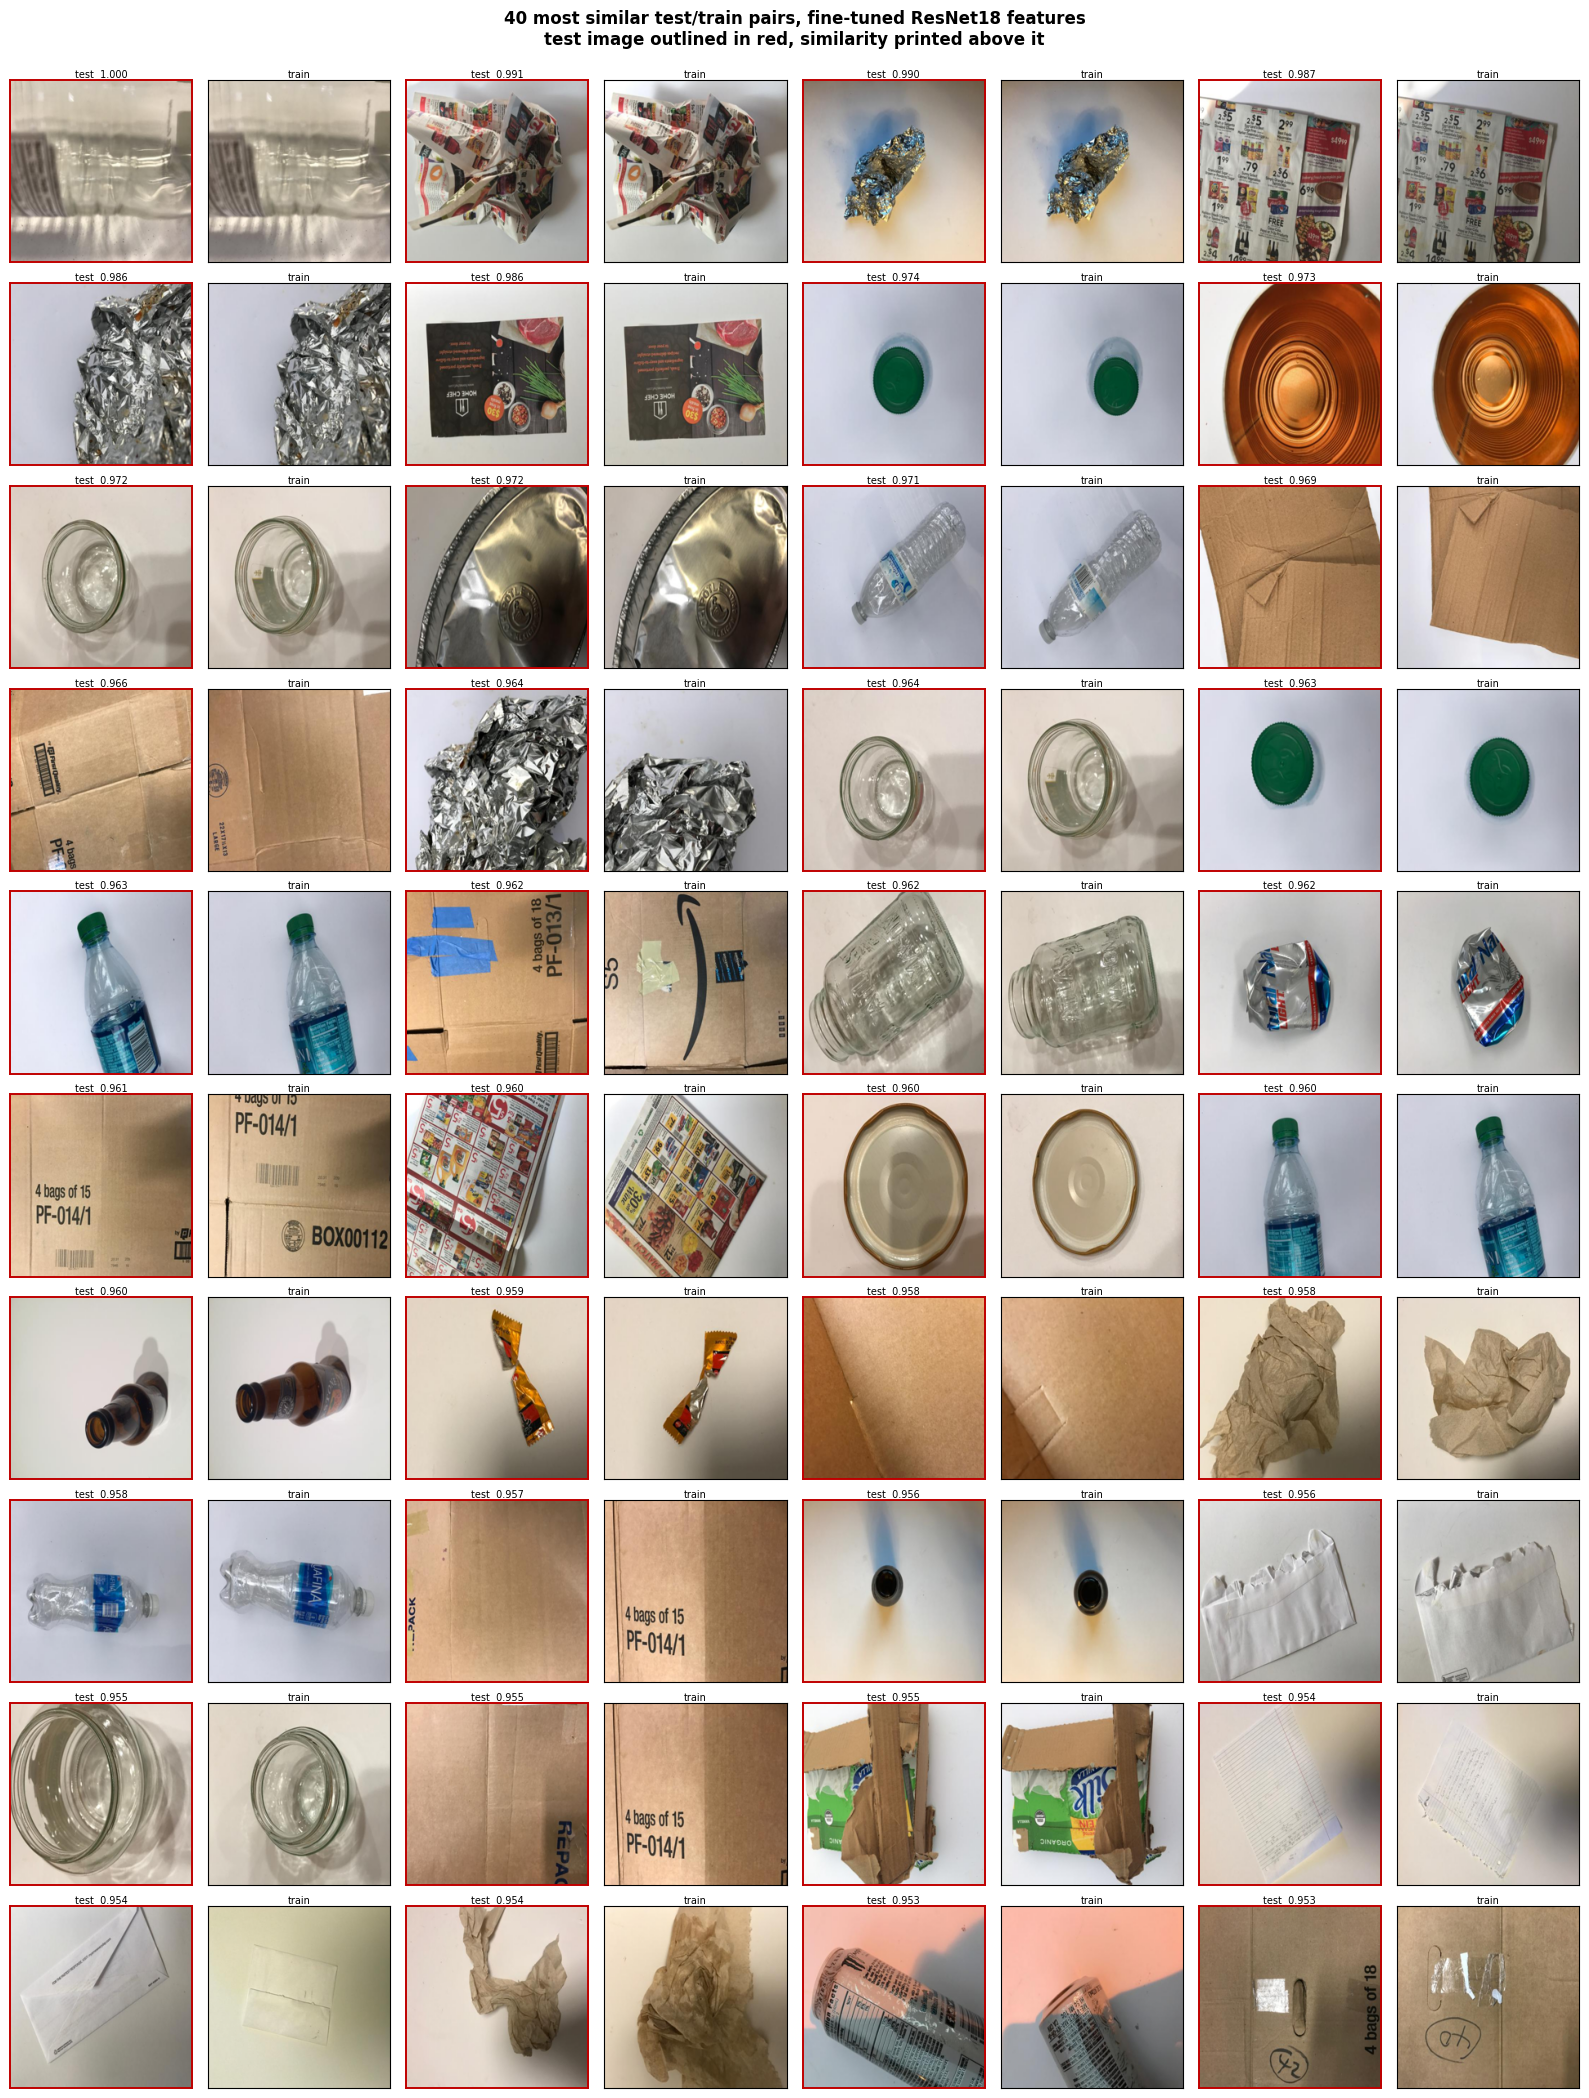

In [15]:
# Contact sheets of the 40 most similar test/train pairs under each basis. These are a check
# on whether the flagging finds genuine same-object pairs, not an input to any number above.

def contact_sheet(similarity_scores, nearest, title, filename):
    order = np.argsort(-similarity_scores)[:40]

    fig, axes = plt.subplots(10, 8, figsize=(16, 21))
    for row in range(10):
        for pair_in_row in range(4):
            position = order[row * 4 + pair_in_row]
            ax_test  = axes[row, pair_in_row * 2]
            ax_train = axes[row, pair_in_row * 2 + 1]

            ax_test.imshow(image_cache[test_idx[position]])
            ax_train.imshow(image_cache[train_idx[nearest[position]]])
            ax_test.set_title(f"test  {similarity_scores[position]:.3f}", fontsize=7, pad=2)
            ax_train.set_title("train", fontsize=7, pad=2)

            for ax in (ax_test, ax_train):
                ax.set_xticks([]); ax.set_yticks([])
            for spine in ax_test.spines.values():
                spine.set_color('#c00000'); spine.set_linewidth(1.4)

    fig.suptitle(title, fontweight='bold', y=0.997)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_PATH, filename), dpi=110)
    plt.show()


contact_sheet(
    max_similarity, nearest_train,
    '40 most similar test/train pairs, fine-tuned ResNet18 features\n'
    'test image outlined in red, similarity printed above it',
    'audit_duplicate_pairs.png'
)

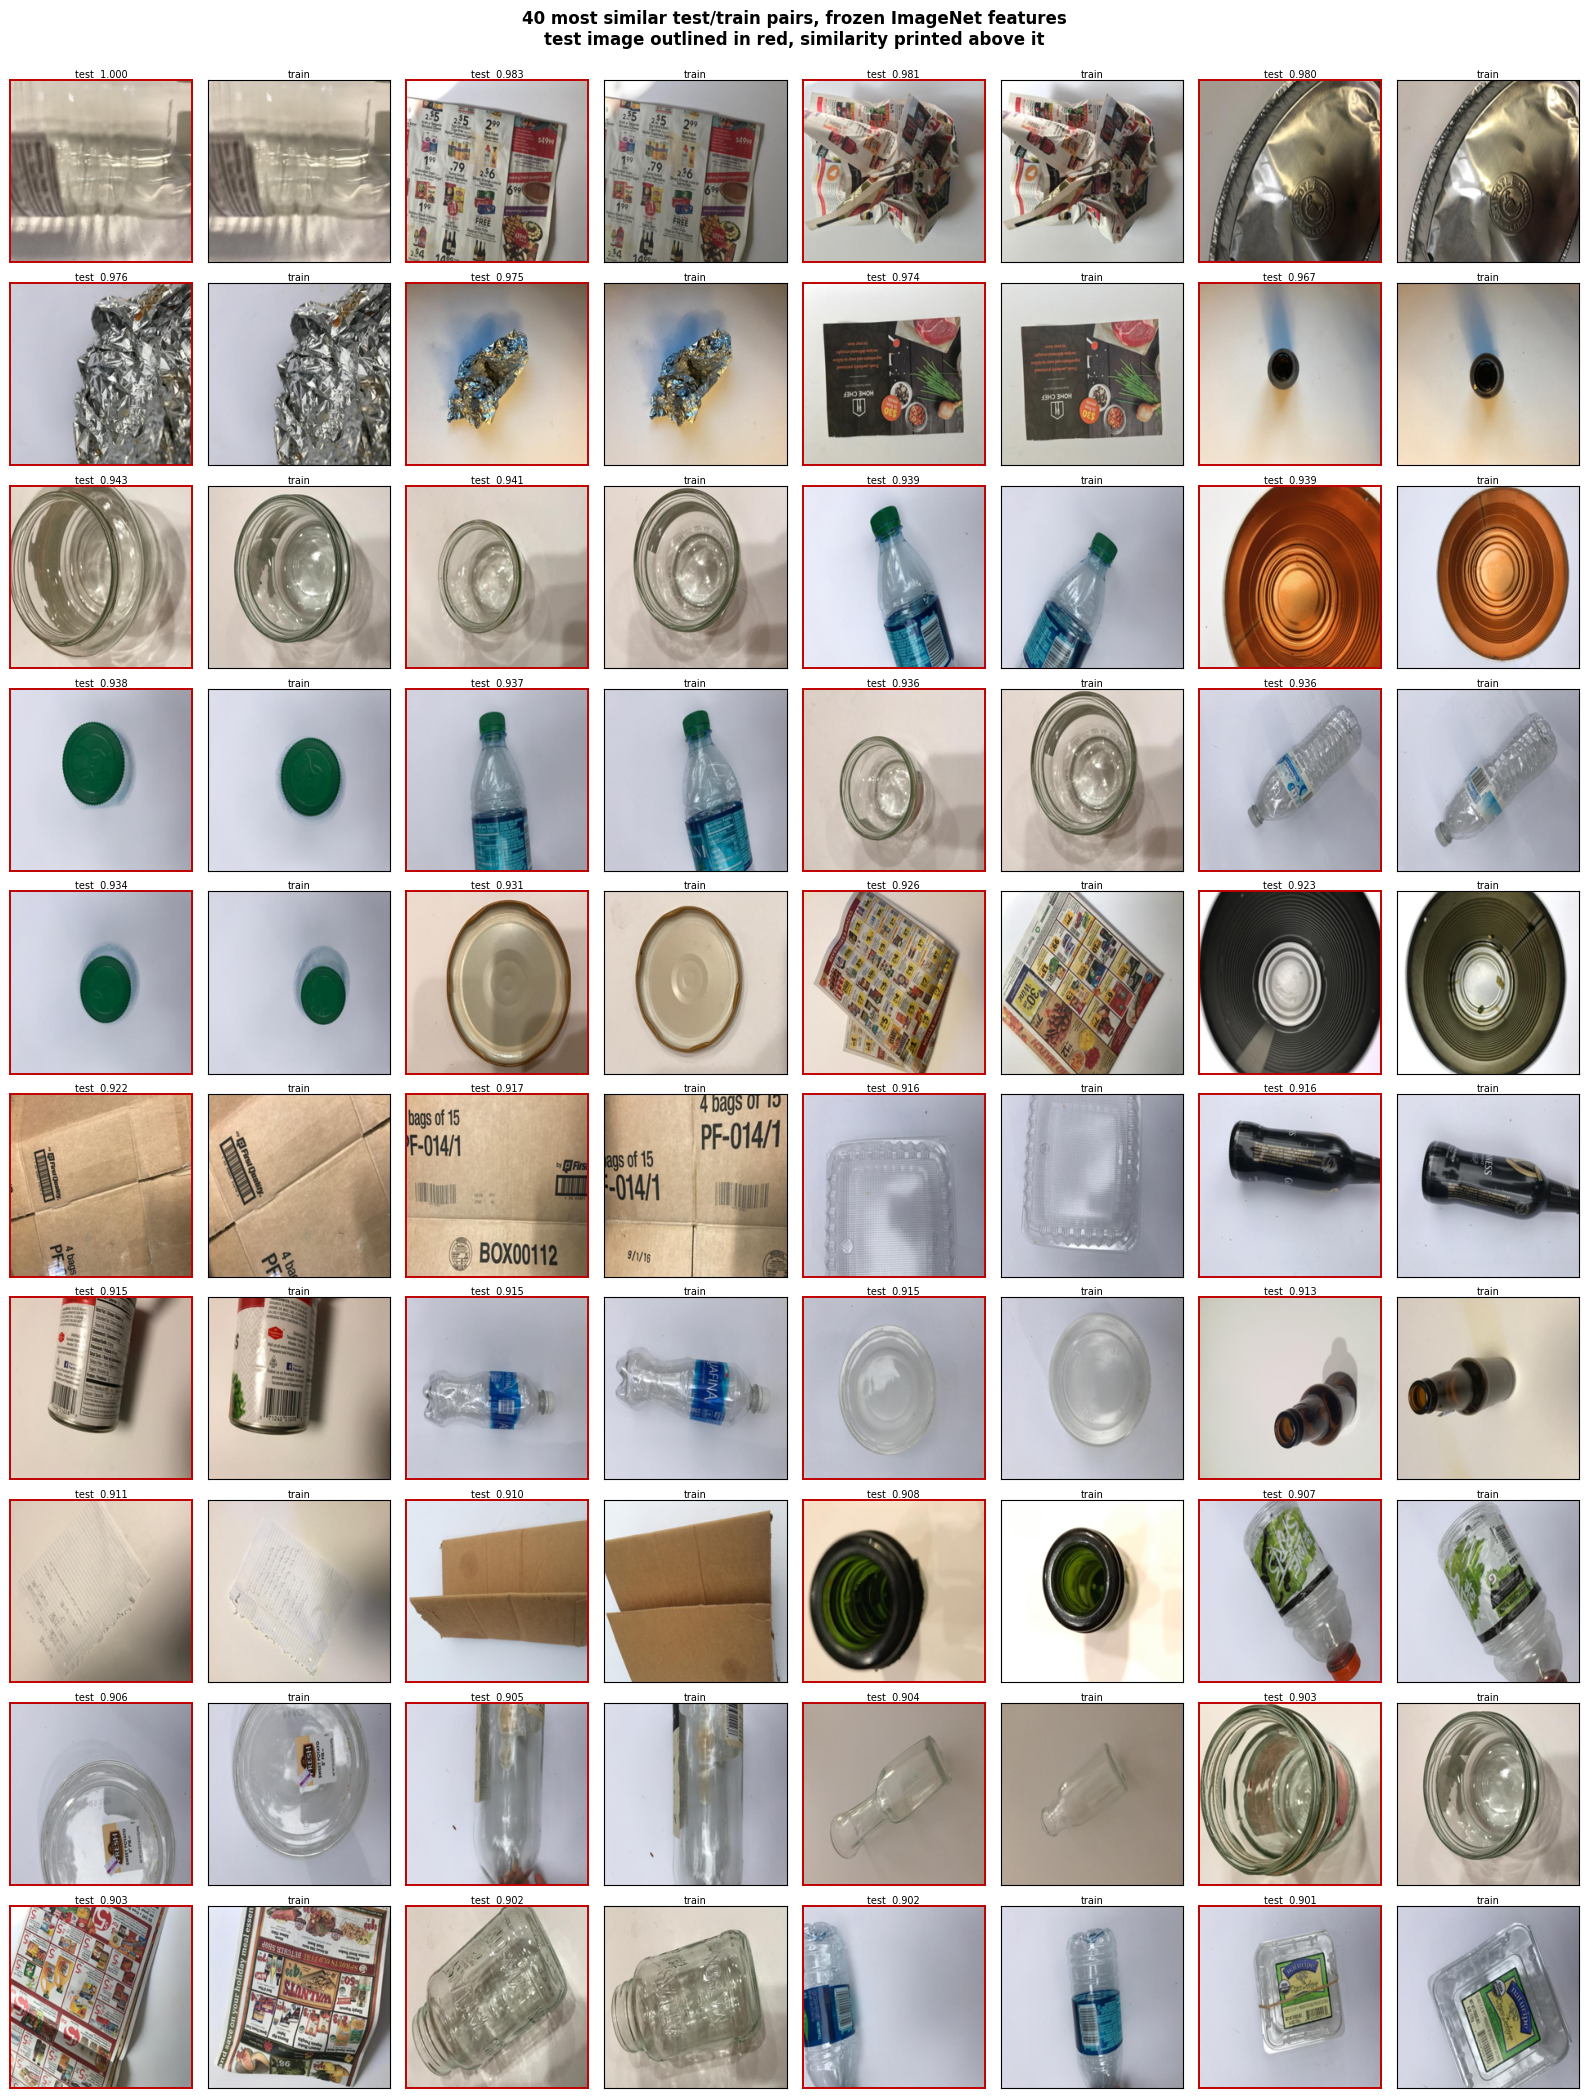

In [16]:
contact_sheet(
    imagenet_max, imagenet_nearest,
    '40 most similar test/train pairs, frozen ImageNet features\n'
    'test image outlined in red, similarity printed above it',
    'audit_duplicate_pairs_frozen.png'
)

In [17]:
# How much of the flagging is class membership rather than object identity. Fine-tuned
# features are trained to collapse within-class distance, so high cosine similarity between
# two images of the same class is expected whether or not they show the same object.

comparison = pd.DataFrame([
    {
        'Threshold': t,
        'Flagged, fine-tuned features': int((max_similarity > t).sum()),
        'Flagged, frozen ImageNet features': int((imagenet_max > t).sum()),
    }
    for t in SIMILARITY_THRESHOLDS
])
comparison.to_csv(os.path.join(RESULTS_PATH, 'audit_similarity_basis_check.csv'), index=False)

print("The two bases disagree about how many images count as near-duplicates:\n")
print(comparison.to_string(index=False))
print(f"\nMedian nearest-train similarity: fine-tuned {np.median(max_similarity):.4f}, "
      f"frozen ImageNet {np.median(imagenet_max):.4f}")

The two bases disagree about how many images count as near-duplicates:

 Threshold  Flagged, fine-tuned features  Flagged, frozen ImageNet features
      0.85                           326                                174
      0.90                           242                                 40
      0.93                           136                                 18
      0.95                            51                                  8
      0.97                            11                                  7

Median nearest-train similarity: fine-tuned 0.9180, frozen ImageNet 0.8443


In [18]:
# Why the CNN pair column is constant at 2 across every threshold, including the 54-image
# subset. If both of the fine-tuned network's glass/metal errors sit in the least similar part
# of the test set, no cutoff removes them, and the column is arithmetic rather than a bug.

is_pair_error = (
    ((cnn_true == 'glass') & (cnn_pred == 'metal'))
    | ((cnn_true == 'metal') & (cnn_pred == 'glass'))
)
positions = np.flatnonzero(is_pair_error)


def rank_of(scores):
    """Rank 1 = most similar to training. Higher rank = further from anything seen."""
    ranks = np.empty(len(scores), int)
    ranks[np.argsort(-scores)] = np.arange(1, len(scores) + 1)
    return ranks


finetuned_ranks = rank_of(max_similarity)
frozen_ranks = rank_of(imagenet_max)

print(f"The fine-tuned network makes {len(positions)} glass/metal errors. "
      f"Where do they sit in the similarity ordering of {len(test_idx)} test images?\n")
for p in positions:
    print(f"  {os.path.basename(image_paths[test_idx[p]]):<16} "
          f"{cnn_true[p]:>5} called {cnn_pred[p]:<5}  "
          f"fine-tuned similarity {max_similarity[p]:.4f} (rank {finetuned_ranks[p]}/{len(test_idx)}), "
          f"frozen {imagenet_max[p]:.4f} (rank {frozen_ranks[p]}/{len(test_idx)})")

print(f"\nMedian rank of a test image is {len(test_idx) // 2}. Both pair errors rank well "
      f"below the median on\nboth bases, meaning they are further from anything in training "
      f"than most test images are,\nso every cutoff keeps them and the CNN pair column stays "
      f"at {len(positions)}.")

The fine-tuned network makes 2 glass/metal errors. Where do they sit in the similarity ordering of 380 test images?

  glass385.jpg     glass called metal  fine-tuned similarity 0.8264 (rank 354/380), frozen 0.8199 (rank 279/380)
  metal317.jpg     metal called glass  fine-tuned similarity 0.8289 (rank 349/380), frozen 0.7987 (rank 325/380)

Median rank of a test image is 190. Both pair errors rank well below the median on
both bases, meaning they are further from anything in training than most test images are,
so every cutoff keeps them and the CNN pair column stays at 2.


### Reading section 2

**The leak is real.** The contact sheet is unambiguous. The closest pair scores 1.000, and
the sheet is full of the same physical object photographed twice: one crumpled newspaper,
one ball of foil, one supermarket flyer, one green bottle cap, one glass jar, one brown beer
bottle, and a cardboard carton stencilled `4 bags of 15 PF-014/1` that turns up in four
separate pairs. These are not unrelated images that happen to score high. TrashNet does put
multiple views of one object on both sides of an image-level split, and every model in this
project benefits from that.

**The two bases agree that the CNN's margin survives it.** This is the result worth having,
because the fine-tuned basis alone would not have been trustworthy. On the frozen ImageNet
features, which were never fitted to these six classes and are independent of both the
fine-tuning and the classical models, the margin over the MLP is 16.5, 15.0, 14.4, 14.5 and
14.5 points at the five cutoffs, against 14.5 points on the full test set, and every subset
holds at least 206 images. On the fine-tuned basis it is 9.3, 17.4, 17.6, 15.2 and 14.6. The
two disagree about how many images to flag and about the shape of the curve, and they agree
on the only thing being asked: removing near-duplicates does not close the gap. Every model
loses accuracy on the cleaned subsets, so the flagged images are easier for all of them
rather than a crutch the CNN alone was leaning on.

**The frozen basis is the better ruler, and it is the better behaved one.** Fine-tuning
pulls same-class images together by construction, so the median test image already sits at
0.918 from its nearest training neighbour and the 0.85 cutoff flags 326 of 380 images, which
is most of the test set rather than a set of duplicates. The frozen features put the median
at 0.844 and flag 174 at the same cutoff, 40 at 0.90 and 7 at 0.97. That is why the
fine-tuned sweep collapses to a 54-image subset at its loosest cutoff and the frozen sweep
never drops below 206. Where the two disagree, prefer the frozen numbers.

**The constant CNN pair column is arithmetic, not a bug.** Both of the fine-tuned network's
glass/metal errors sit in the least similar part of the test set: `glass385.jpg` ranks
354th of 380 by similarity to training and `metal317.jpg` ranks 349th, against a median rank
of 190, and both stay below the median on the frozen basis too at 279th and 325th. No cutoff
removes them, so the column reads 2 all the way down to the 54-image subset. Its two residual
errors on this pair are on objects further from anything in training than most test images
are, which is the opposite of what memorisation would look like.

## 3. Five seeds on the fine-tuned CNN

Notebook 15 measures the RF and MLP over seeds 42, 1, 7, 13 and 99, with the seed driving the
split as well as the model. The same sweep is run here for the fine-tuned ResNet18, so the
glass/metal count of 2 can be read against its own spread rather than as a fixed quantity.

Nothing here is written to `cnn_final_model.pt`. The seed-42 run below is a fresh training
run for variance measurement and should reproduce the committed model, which is itself a
check that notebook 16 is reproducible.

In [19]:
seed_rows = []

for seed in SEEDS:
    seed_train, seed_val, seed_test = split_indices(all_labels, seed)
    model, _, best_epoch, best_val = train_resnet(
        seed_train, seed_val, seed, pretrained=True, label=f"seed {seed}"
    )
    pred, true = predict(model, make_loader(seed_test))
    s = score(true, pred)
    seed_rows.append({
        'Seed': seed,
        'Best epoch': best_epoch,
        'Val accuracy': round(best_val, 4),
        'Accuracy': round(s['Accuracy'], 4),
        'Glass/metal pair': s['Pair'],
        'Total errors': s['Errors'],
    })
    print(f"  seed {seed}: accuracy {s['Accuracy']:.4f}, pair {s['Pair']}, errors {s['Errors']}")

seed_sweep = pd.DataFrame(seed_rows)
seed_sweep.to_csv(os.path.join(RESULTS_PATH, 'audit_cnn_seed_sweep.csv'), index=False)

print()
print(seed_sweep.to_string(index=False))

  seed 42 trained in 105s, best val 0.9524 at epoch 17


  seed 42: accuracy 0.9500, pair 2, errors 19


  seed 1 trained in 105s, best val 0.9365 at epoch 16


  seed 1: accuracy 0.9211, pair 6, errors 30


  seed 7 trained in 105s, best val 0.9550 at epoch 12


  seed 7: accuracy 0.9105, pair 6, errors 34


  seed 13 trained in 105s, best val 0.9206 at epoch 6


  seed 13: accuracy 0.9026, pair 13, errors 37


  seed 99 trained in 105s, best val 0.9312 at epoch 13


  seed 99: accuracy 0.9237, pair 11, errors 29

 Seed  Best epoch  Val accuracy  Accuracy  Glass/metal pair  Total errors
   42          17        0.9524    0.9500                 2            19
    1          16        0.9365    0.9211                 6            30
    7          12        0.9550    0.9105                 6            34
   13           6        0.9206    0.9026                13            37
   99          13        0.9312    0.9237                11            29


In [20]:
summary_stats = seed_sweep[['Accuracy', 'Glass/metal pair', 'Total errors']].agg(['mean', 'std'])
print("Five-seed spread for the fine-tuned ResNet18:\n")
print(summary_stats.round(4).to_string())

print(f"\nAccuracy         {seed_sweep['Accuracy'].mean():.4f} +/- {seed_sweep['Accuracy'].std():.4f}")
print(f"Glass/metal pair {seed_sweep['Glass/metal pair'].mean():.2f} +/- "
      f"{seed_sweep['Glass/metal pair'].std():.2f}  "
      f"(range {seed_sweep['Glass/metal pair'].min()} to {seed_sweep['Glass/metal pair'].max()})")
print(f"Total errors     {seed_sweep['Total errors'].mean():.2f} +/- "
      f"{seed_sweep['Total errors'].std():.2f}")

seed42 = seed_sweep[seed_sweep['Seed'] == 42].iloc[0]
committed_pair, committed_errors = pair_and_errors(cnn_cm_committed)
print(f"\nSeed 42 here: accuracy {seed42['Accuracy']:.4f}, pair {seed42['Glass/metal pair']}, "
      f"errors {seed42['Total errors']}")
print(f"Committed notebook 16: accuracy {np.trace(cnn_cm_committed) / cnn_cm_committed.sum():.4f}, "
      f"pair {committed_pair}, errors {committed_errors}")

Five-seed spread for the fine-tuned ResNet18:

      Accuracy  Glass/metal pair  Total errors
mean    0.9216            7.6000       29.8000
std     0.0180            4.3932        6.8337

Accuracy         0.9216 +/- 0.0180
Glass/metal pair 7.60 +/- 4.39  (range 2 to 13)
Total errors     29.80 +/- 6.83

Seed 42 here: accuracy 0.9500, pair 2.0, errors 19.0
Committed notebook 16: accuracy 0.9500, pair 2, errors 19


In [21]:
# The pair as a share of each model's own errors. This is the number that controls for a more
# accurate model making fewer of every kind of mistake, and it is computed per seed for the
# fine-tuned network because the seed-42 value turned out to be its extreme.

seed_sweep['Pair share'] = (seed_sweep['Glass/metal pair'] / seed_sweep['Total errors']).round(4)

share_rows = []
for name, filename in CLASSICAL.items():
    cm = np.load(os.path.join(RESULTS_PATH, filename))
    pair, errors = pair_and_errors(cm)
    share_rows.append({'Model': name, 'Seeds': 1, 'Pair': pair, 'Errors': errors,
                       'Pair share': pair / errors, 'Pair share std': np.nan})

for name, frame in [('Frozen ImageNet probe', probe_seeds),
                    ('ResNet18 from scratch', scratch_seeds)]:
    share_rows.append({'Model': name, 'Seeds': len(frame), 'Pair': frame['Pair'].mean(),
                       'Errors': frame['Errors'].mean(),
                       'Pair share': frame['Pair share'].mean(),
                       'Pair share std': frame['Pair share'].std()})

share_rows.append({
    'Model': 'ResNet18 fine-tuned', 'Seeds': len(seed_sweep),
    'Pair': seed_sweep['Glass/metal pair'].mean(), 'Errors': seed_sweep['Total errors'].mean(),
    'Pair share': seed_sweep['Pair share'].mean(),
    'Pair share std': seed_sweep['Pair share'].std(),
})

pair_share = pd.DataFrame(share_rows)
pair_share['Pair share %'] = (pair_share['Pair share'] * 100).round(1)
pair_share['Pair share std %'] = (pair_share['Pair share std'] * 100).round(1)
pair_share.drop(columns=['Pair share', 'Pair share std']).to_csv(
    os.path.join(RESULTS_PATH, 'audit_pair_share.csv'), index=False
)

print("Glass/metal pair as a share of each model's own errors:\n")
print(pair_share[['Model', 'Seeds', 'Pair', 'Errors', 'Pair share %', 'Pair share std %']]
      .to_string(index=False))

print(f"\nFine-tuned network per seed: "
      f"{[f'{s * 100:.1f}%' for s in seed_sweep['Pair share']]}")
print(f"Mean {seed_sweep['Pair share'].mean() * 100:.1f}% "
      f"+/- {seed_sweep['Pair share'].std() * 100:.1f}")

band = pair_share['Pair share %']
print(f"\nRange across all {len(pair_share)} representations: "
      f"{band.min():.1f}% to {band.max():.1f}%")

Glass/metal pair as a share of each model's own errors:

                        Model  Seeds  Pair  Errors  Pair share %  Pair share std %
Logistic Regression (122-dim)      1  21.0   118.0          17.8               NaN
         Linear SVC (122-dim)      1  25.0   125.0          20.0               NaN
      Random Forest (122-dim)      1  16.0    80.0          20.0               NaN
                MLP (122-dim)      1  17.0    74.0          23.0               NaN
        Frozen ImageNet probe      5  13.8    63.2          21.8               3.1
        ResNet18 from scratch      5  17.4    78.4          22.1               4.5
          ResNet18 fine-tuned      5   7.6    29.8          24.2              11.8

Fine-tuned network per seed: ['10.5%', '20.0%', '17.6%', '35.1%', '37.9%']
Mean 24.2% +/- 11.8

Range across all 7 representations: 17.8% to 24.2%


In [22]:
# Where the classical models sit for comparison, from notebook 15's committed sweep.

seed_sweep_classical = pd.read_csv(os.path.join(RESULTS_PATH, 'seed_sweep.csv'))
print("Notebook 15's classical seed sweep, for reference:\n")
print(seed_sweep_classical.to_string(index=False))

Notebook 15's classical seed sweep, for reference:

 seed         model  accuracy  weighted_f1  macro_f1  macro_recovery
   42 Random Forest  0.789474     0.789810  0.774748        0.638090
   42           MLP  0.805263     0.805543  0.791396        0.660464
    1 Random Forest  0.776316     0.773939  0.748688        0.606544
    1           MLP  0.797368     0.796918  0.773294        0.636049
    7 Random Forest  0.760526     0.757497  0.729635        0.583255
    7           MLP  0.800000     0.799948  0.793078        0.660811
   13 Random Forest  0.794737     0.791930  0.771700        0.635216
   13           MLP  0.773684     0.773703  0.748863        0.606701
   99 Random Forest  0.776316     0.769843  0.726981        0.591992
   99           MLP  0.826316     0.826131  0.814876        0.692266


### Reading section 3

This is the check that forces a rewrite.

**Seed 42 is the best of the five on every column.** Accuracy 95.00% against a five-seed
mean of 92.16% ± 1.80. Glass/metal pair 2 against a mean of 7.60 ± 4.39, spanning 2 to 13.
Total errors 19 against 29.80 ± 6.83. The seed the whole project reports is not a typical
draw for this model, it is the favourable tail of one.

**The accuracy advantage is solid.** 92.16% ± 1.80 against notebook 15's 80.05% ± 1.88 for
the MLP and 77.95% ± 1.33 for the RF is a twelve-point gap against spreads of about two
points. Nothing about the seed sweep threatens the claim that the fine-tuned CNN is far more
accurate, and the seed sweep is the same instrument notebook 15 used to refuse the RF/MLP
gap, so it is being applied consistently rather than selectively.

**The glass/metal count is not solid.** A pair count of 7.60 ± 4.39 cannot support sentences
built on the number 2. At seed 13 the pair is 13, which sits inside the range the RF (16) and
MLP (17) occupy and is not distinguishable from them on 380 images. The reduction is real on
average, from 16 and 17 down to about 8, but it is roughly a halving with a wide spread
rather than the eightfold collapse the README currently reports. Any sentence that reads the
residual structure of the CNN's errors, such as which pair is now largest or what share of
errors glass and metal account for, is reading noise.

**Notebook 16 is reproducible; it was lucky.** The seed-42 run here reproduces the committed
model exactly, at 95.00% with pair 2 and 19 errors, from a fresh training run in a different
process. So there is no bug to fix in notebook 16. The problem is that a single seed was
reported as though it were the model's behaviour, which is exactly the error notebook 15
exists to prevent.

## Summary

The three checks, against what finding 1 claimed before this notebook ran.

**What survives.** The fine-tuned CNN is far more accurate than anything else in the project,
by twelve points against seed noise of about two, and that margin does not depend on
near-duplicate leakage under either similarity basis. The claim that the representation and
not the classifier sets the accuracy ceiling also survives: four classifiers on the same 122
dimensions span 67% to 81%, and changing the representation is worth more than changing the
classifier family ever was.

**What does not survive.** Three things.

The images were not held fixed. The ResNet18 saw 1.28 million ImageNet images first, and that
matters: across five seeds ImageNet alone puts 13.8 on the pair and TrashNet alone puts 17.4,
against 16 and 17 for the classical models. The from-scratch network does not beat the MLP on
accuracy either, at 79.37% against 80.05%.

The number 2 is one seed. Across seeds the pair is 7.6 ± 4.4 and reaches 13, which is not
separable from the RF's 16. The eightfold collapse is a seed-42 artifact; a halving of the
absolute count is what the evidence supports.

The pair did not become relatively easier. As a share of each model's own errors it is 17.8%
for logistic regression, 20.0% for the linear SVC and the RF, 23.0% for the MLP, 21.8% for
the frozen probe, 22.1% for the from-scratch network and 24.2% ± 11.8 for the fine-tuned one.
Seven representations, every one of them losing between about a fifth and a quarter of its
errors to this single pair. The fine-tuned network's count falls because its total errors
fall. That is the opposite of what the first version of this notebook concluded from seed
42's 10.5%, and it partly reinstates the reading finding 1 had withdrawn.

**What the split by image costs everyone.** The leak is confirmed visually and affects all
models. It is a limitation of the dataset and of every number in this repository, not of the
CNN specifically.

In [23]:
print("1. Where the glass/metal fix came from")
print(representation[['Model', 'Accuracy', 'Glass/metal pair', 'Total errors']].to_string(index=False))
print()
print("2. Duplicate audit, CNN margin over the MLP across thresholds")
print(sweep[['Threshold', 'Flagged', 'Subset size', 'RF accuracy', 'MLP accuracy',
             'CNN accuracy', 'CNN minus MLP', 'CNN pair']].to_string(index=False))
print()
print("3. Five-seed spread of the fine-tuned CNN")
print(seed_sweep.to_string(index=False))

1. Where the glass/metal fix came from
                                     Model  Accuracy  Glass/metal pair  Total errors
             Logistic Regression (122-dim)    0.6895              21.0         118.0
                      Linear SVC (122-dim)    0.6711              25.0         125.0
                   Random Forest (122-dim)    0.7895              16.0          80.0
                             MLP (122-dim)    0.8053              17.0          74.0
           ResNet18 from scratch (seed 42)    0.8079              13.0          73.0
       ResNet18 from scratch (5-seed mean)    0.7937              17.4          78.4
           Frozen ImageNet probe (seed 42)    0.8500              12.0          57.0
       Frozen ImageNet probe (5-seed mean)    0.8337              13.8          63.2
ResNet18 fine-tuned (seed 42, notebook 16)    0.9500               2.0          19.0

2. Duplicate audit, CNN margin over the MLP across thresholds
 Threshold  Flagged  Subset size  RF accuracy  M